In [15]:
import numpy as np
import os
import sys
# Get the absolute path to the project root directory
project_root = '/common/users/ql236/human_trajectory_prediction/ProjectJTP/'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from SingularTrajectory.space import SingularSpace

from sdd_loader import SDDTrajDataset
from utils import *
from SingularTrajectory.normalizer import TrajNorm


In [6]:
config = get_exp_config(os.path.join(project_root, "prepare/config/sdd_anchor.json"))

In [84]:
anchor_path = os.path.join(project_root, 'prepare/sdd_250/trajectory_prototypes.npy')
anchors = torch.from_numpy(np.load(anchor_path))
print(anchors.shape)

torch.Size([250, 12, 2])


In [79]:
data_dir = os.path.join(project_root, 'data/SDD/test', config.dataset)
traj_dataset = SDDTrajDataset(data_dir, mode='test')
singular_space = SingularSpace(hyper_params=config,
                            norm_ori=True, 
                            norm_rot=True, 
                            norm_sca=False)


  0%|          | 0/17 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:26<00:00,  1.56s/it]

Loaded 2749 trajectories from test set of SDD.


In [47]:
normalizer = TrajNorm(ori=True, rot=True, sca=False)

In [85]:
obs_traj, pred_traj = traj_dataset.obs_traj, traj_dataset.pred_traj
normalizer.calculate_params(obs_traj)
pred_traj_norm = normalizer.normalize(pred_traj)

anchor_errors = []
pred_traj_norm.shape

pred_traj_norm_expand = pred_traj_norm.unsqueeze(1).repeat(1, anchors.shape[0], 1, 1)
anchors_expand = anchors.unsqueeze(0).repeat(pred_traj_norm.shape[0], 1, 1, 1)
errors = torch.norm(pred_traj_norm_expand - anchors_expand, dim=-1)[...,-1]  # (num_samples, num_anchors)
errors.min(1)[0].mean()

tensor(6.6791)

In [81]:
num_agent = pred_traj.shape[0]
num_anchor = anchors.shape[0]
all_anchor_errors = []
for a in range(num_agent):
    obs = traj_dataset.obs_traj[a]  # (obs_len, 2)
    obs = obs.unsqueeze(0).repeat(num_anchor, 1, 1)  # (num_anchor, obs_len, 2)
    pred = traj_dataset.pred_traj[a]  # (pred_len, 2)
    normalizer.calculate_params(obs)
    anchor_denorm = normalizer.denormalize(anchors)  # (num_anchor, pred_len, 2)
    errors = torch.norm(pred.unsqueeze(0) - anchor_denorm, dim=-1)[...,-1]  # (num_anchor,)
    all_anchor_errors.append(errors)

all_anchor_errors = torch.stack(all_anchor_errors, dim=0)  # (num_agent, num_anchor)
all_anchor_errors.min(1)[0].mean()

    
    
    

tensor(4.8165)

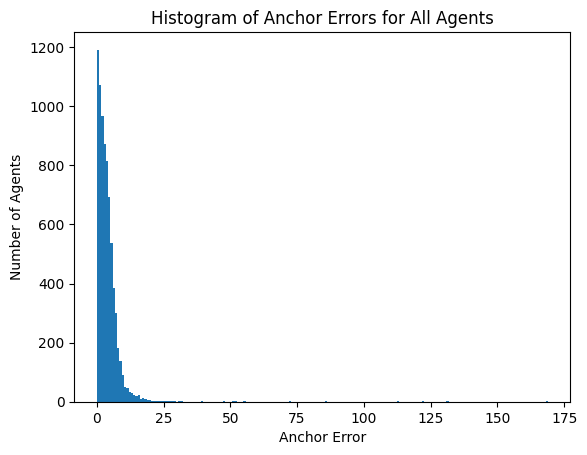

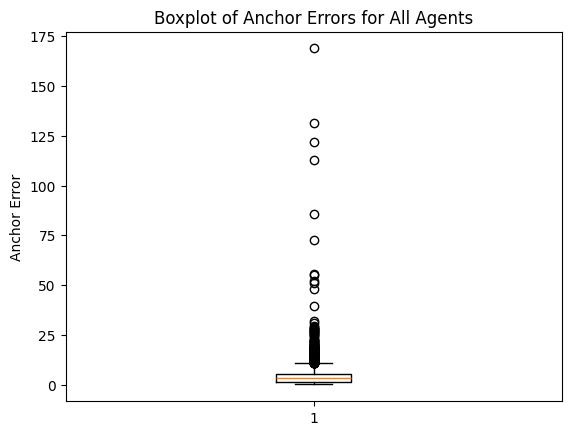

In [76]:
# plot all_anchor_errors
import matplotlib.pyplot as plt

gt_anchor_error = all_anchor_errors.min(1)[0]  # (num_agent,)
plt.hist(gt_anchor_error.numpy(), bins=200)
plt.xlabel('Anchor Error')
plt.ylabel('Number of Agents')
plt.title('Histogram of Anchor Errors for All Agents')
plt.show()

# plot boxplot
plt.boxplot(gt_anchor_error.numpy())
plt.ylabel('Anchor Error')
plt.title('Boxplot of Anchor Errors for All Agents')
plt.show()